In [1]:
import numpy as np
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor

In [2]:
# Set the same seed for both
seed = 42

# For statsmodels
np.random.seed(seed) 

# For PyMC-extras
rng = np.random.default_rng(seed)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

def simulate_dfm_trajectory(params_dict, n_steps=100, random_seed=42):
    """
    Custom function to simulate trajectories from a Dynamic Factor Model
    
    Parameters:
    -----------
    params_dict : dict
        Dictionary containing DFM parameters:
        - 'factor_loadings': (n_endog, n_factors) array
        - 'factor_ar': (n_factors, n_factors) array or scalar
        - 'error_ar': (n_endog,) array for AR(1) error terms
        - 'error_sigma': (n_endog,) array of error standard deviations
        - 'factor_sigma': scalar or (n_factors,) array for factor innovations
    n_steps : int
        Number of time steps to simulate
    random_seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    factors : ndarray of shape (n_steps, n_factors)
        Simulated factor trajectories
    observations : ndarray of shape (n_steps, n_endog)
        Simulated observed variables
    """
    
    # Set random seed
    rng = np.random.default_rng(random_seed)
    
    # Extract parameters
    factor_loadings = params_dict['factor_loadings']  # (n_endog, n_factors)
    factor_ar = np.atleast_2d(params_dict['factor_ar'])  # (n_factors, n_factors)
    error_ar = np.array(params_dict['error_ar'])  # (n_endog,)
    error_sigma = np.array(params_dict['error_sigma'])  # (n_endog,)
    factor_sigma = params_dict.get('factor_sigma', 1.0)  # scalar or (n_factors,)
    
    # Dimensions
    n_endog, n_factors = factor_loadings.shape
    
    # Initialize arrays
    factors = np.zeros((n_steps, n_factors))
    observations = np.zeros((n_steps, n_endog))
    error_terms = np.zeros((n_steps, n_endog))  # AR(1) error terms
    
    # Initial conditions 
    factors[0] = np.zeros(n_factors)  # Start with zero factors
    error_terms[0] = rng.normal(0, error_sigma)
    
    # Initial observations
    observations[0] = factor_loadings @ factors[0] + error_terms[0]
    
    # Simulate trajectory
    for t in range(1, n_steps):
        # Factor evolution: f_t = φ * f_{t-1} + η_t
        factor_innovations = rng.normal(0, np.sqrt(factor_sigma), n_factors)
        factors[t] = factor_ar @ factors[t-1] + factor_innovations
        
        # Error term evolution: e_t = ρ * e_{t-1} + ε_t
        error_innovations = rng.normal(0, error_sigma)
        error_terms[t] = error_ar * error_terms[t-1] + error_innovations
        
        # Observations: y_t = Λ * f_t + e_t
        observations[t] = factor_loadings @ factors[t] + error_terms[t]
    
    return factors, observations

def simulate_statsmodels_dfm(mod, params, n_obs=100, random_seed=42):
    """
    Wrapper to simulate from statsmodels DFM using custom simulation
    
    Parameters:
    -----------
    mod : statsmodels DynamicFactor model
    params : array-like
        Parameters in statsmodels format
    n_obs : int
        Number of observations
    random_seed : int
        Random seed
        
    Returns:
    --------
    observations : ndarray
        Simulated observations
    """
    
    # Update model with parameters
    mod.update(params)
    
    # Extract state-space matrices
    Z = mod.ssm['design']  # Design matrix (factor loadings)
    T = mod.ssm['transition']  # Transition matrix
    Q = mod.ssm['state_cov']  # State covariance
    
    # Convert to our parameter format
    # Note: This assumes specific model structure - adjust as needed
    factor_loadings = Z[:, 0].reshape(-1, 1)  # First column for single factor
    factor_ar = T[0, 0]  # Factor AR coefficient
    error_ar = np.diag(T[1:, 1:])  # Error AR coefficients
    error_sigma = np.sqrt(np.diag(Q[1:, 1:]))  # Error standard deviations
    factor_sigma = Q[0, 0]  # Factor innovation variance
    
    params_dict = {
        'factor_loadings': factor_loadings,
        'factor_ar': factor_ar,
        'error_ar': error_ar,
        'error_sigma': error_sigma,
        'factor_sigma': factor_sigma
    }
    
    factors, observations = simulate_dfm_trajectory(params_dict, n_obs, random_seed)
    return observations

def simulate_pymc_dfm(param_dict, n_steps=100, random_seed=42):
    """
    Wrapper to simulate from PyMC-extras DFM format
    
    Parameters:
    -----------
    param_dict : dict
        PyMC-extras parameter dictionary
    n_steps : int
        Number of steps
    random_seed : int
        Random seed
        
    Returns:
    --------
    observations : ndarray
        Simulated observations
    """
    
    # Convert PyMC format to our format
    params_dict = {
        'factor_loadings': param_dict['factor_loadings'],
        'factor_ar': param_dict['factor_ar'][0, 0],  # Extract scalar
        'error_ar': param_dict['error_ar'].flatten(),
        'error_sigma': param_dict['error_sigma'],
        'factor_sigma': 1.0  # Default factor innovation variance
    }
    
    factors, observations = simulate_dfm_trajectory(params_dict, n_steps, random_seed)
    return observations

# Example usage and comparison
def compare_simulations():
    """
    Compare simulations from both frameworks
    """
    
    # Define common parameters
    params_dict = {
        'factor_loadings': np.array([[0.9], [0.8]]),
        'factor_ar': 0.5,
        'error_ar': np.array([0.4, 0.3]),
        'error_sigma': np.array([0.7, 0.6]),
        'factor_sigma': 1.0
    }
    
    # Simulate using custom function
    factors, observations = simulate_dfm_trajectory(params_dict, n_steps=100, random_seed=42)
    
    print("Custom simulation completed successfully!")
    print(f"Factors shape: {factors.shape}")
    print(f"Observations shape: {observations.shape}")
    print(f"First 5 observations:")
    print(observations[:5])
    
    # Plot results
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.plot(factors)
    plt.title('Simulated Factors')
    plt.ylabel('Factor Values')
    
    plt.subplot(2, 2, 2)
    plt.plot(observations[:, 0], label='Variable 1')
    plt.plot(observations[:, 1], label='Variable 2')
    plt.title('Simulated Observations')
    plt.ylabel('Observed Values')
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.scatter(observations[:, 0], observations[:, 1])
    plt.xlabel('Variable 1')
    plt.ylabel('Variable 2')
    plt.title('Scatter Plot of Variables')
    
    plt.subplot(2, 2, 4)
    plt.plot(np.cumsum(observations, axis=0))
    plt.title('Cumulative Sum of Observations')
    plt.ylabel('Cumulative Values')
    
    plt.tight_layout()
    plt.show()
    
    return factors, observations

def validate_with_statsmodels():
    """
    Validate our custom simulation against statsmodels format
    """
    
    # Create sample data for statsmodels
    from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
    
    # Initialize with dummy data
    n_obs = 100
    endog = np.zeros((n_obs, 2))
    
    # Create model
    mod = DynamicFactor(endog, k_factors=1, factor_order=1, error_order=1)
    
    # Parameters in statsmodels format
    params = [0.9, 0.8,    # factor loadings
              0.7, 0.6,    # error variances
              0.5,         # factor AR coefficient  
              0.4, 0.3]    # error AR coefficients
    
    # Our custom parameters
    params_dict = {
        'factor_loadings': np.array([[0.9], [0.8]]),
        'factor_ar': 0.5,
        'error_ar': np.array([0.4, 0.3]),
        'error_sigma': np.array([np.sqrt(0.7), np.sqrt(0.6)]),  # Convert variance to std
        'factor_sigma': 1.0
    }
    
    # Compare simulations
    print("Comparing simulations...")
    
    # Custom simulation
    factors_custom, obs_custom = simulate_dfm_trajectory(params_dict, n_steps=100, random_seed=42)
    
    # Alternative using different seed to show variability
    factors_alt, obs_alt = simulate_dfm_trajectory(params_dict, n_steps=100, random_seed=123)
    
    print("Custom simulation 1 (seed=42):")
    print("First 3 observations:", obs_custom[:3])
    print("Last 3 observations:", obs_custom[-3:])
    
    print("\nCustom simulation 2 (seed=123):")
    print("First 3 observations:", obs_alt[:3])
    print("Last 3 observations:", obs_alt[-3:])
    
    # Statistical properties
    print(f"\nStatistical properties (seed=42):")
    print(f"Observations mean: {np.mean(obs_custom, axis=0)}")
    print(f"Observations std: {np.std(obs_custom, axis=0)}")
    print(f"Factor-observation correlation: {np.corrcoef(factors_custom[:, 0], obs_custom[:, 0])[0, 1]:.3f}, {np.corrcoef(factors_custom[:, 0], obs_custom[:, 1])[0, 1]:.3f}")
    
    return obs_custom, obs_alt

In [4]:


# Example parameters
n_obs = 100
endog = np.random.normal(size=(n_obs, 2))  # placeholder, just to initialize
exog = np.ones((n_obs, 1))  # constant exogenous variable

mod = DynamicFactor(endog, k_factors=1, factor_order=1, error_order=1) #, exog=exog)


In [5]:
# Overwrite initialization to custom values
mod.ssm.initialize_known(
    constant=np.zeros((3,)),  # x0 (size = k_states)
    stationary_cov=np.zeros((3,3)) # P0
)

In [6]:



print(mod.param_names)

# # Arbitrary fixed params (just for simulation)
# params = np.array([0.9, 0.8, # factor loadings
#                    0.7, 0.6, # betas 2

#                    0., 0.4, # error sigmas

#                    0.3, # factor ar
#                    0.2, 0.1 # error order
#                    ])  # match model param ordering

params = [0.9, 0.8,    # factor loadings
          0.7, 0.6,    # error variances (sigma²)
          0.5,         # factor AR coefficient  
          0.4, 0.3]    # error AR coefficients

# Simulate trajectory
# simulated_data = mod.simulate(params, n_obs)
# print(simulated_data[:5])

['loading.f1.y1', 'loading.f1.y2', 'sigma2.y1', 'sigma2.y2', 'L1.f1.f1', 'L1.e(y1).e(y1)', 'L1.e(y2).e(y2)']


In [7]:
simulate_statsmodels_dfm(mod, params, n_obs=100, random_seed=42)

array([[ 2.54944600e-01, -8.05568225e-01],
       [ 1.56431682e+00, -1.15257487e+00],
       [-3.71735267e-01, -1.51240433e+00],
       [-9.60948755e-01,  6.57038907e-02],
       [ 3.27653455e-01,  1.43825750e+00],
       [-1.18727106e-01,  1.17714231e+00],
       [-1.09250710e-01, -3.34822106e-01],
       [-8.32947266e-01,  6.04125573e-01],
       [-8.73839982e-01, -2.91982544e-01],
       [ 3.99777174e-01,  5.94811597e-01],
       [ 2.36962977e+00,  2.61890886e-01],
       [-1.40169243e-01,  2.41639213e-01],
       [ 8.45494447e-01,  2.90793614e-01],
       [ 2.32508352e-01,  1.66964096e-01],
       [-3.15715247e-03,  6.14321426e-01],
       [ 3.21509276e-01,  1.01449428e+00],
       [ 9.25754717e-01,  5.85162666e-01],
       [ 1.19275416e+00, -6.61292728e-01],
       [-1.61088091e-01, -8.72452842e-01],
       [ 9.31452135e-01, -1.16539465e+00],
       [-1.92342417e-01,  1.15143154e-01],
       [ 6.32962674e-01,  8.45353522e-01],
       [ 7.26557574e-01,  6.21035368e-01],
       [ 9.

In [8]:
# Update the model's state-space representation with the parameters
mod.update(params)

# Access state-space system matrices
print("Design matrix (Z):\n", mod.ssm['design'])
print("Transition matrix (T):\n", mod.ssm['transition'])
print("Selection matrix (R):\n", mod.ssm['selection'])
print("State covariance matrix (Q):\n", mod.ssm['state_cov'])
print("Observation intercept (d):\n", mod.ssm['obs_intercept'])
print("State intercept (c):\n", mod.ssm['state_intercept'])

Design matrix (Z):
 [[0.9 1.  0. ]
 [0.8 0.  1. ]]
Transition matrix (T):
 [[0.5 0.  0. ]
 [0.  0.4 0. ]
 [0.  0.  0.3]]
Selection matrix (R):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
State covariance matrix (Q):
 [[1.  0.  0. ]
 [0.  0.7 0. ]
 [0.  0.  0.6]]
Observation intercept (d):
 [0. 0.]
State intercept (c):
 [0. 0. 0.]


In [9]:
from pymc_extras.statespace.models.DFM import BayesianDynamicFactor

In [22]:
# Create DFM Statespace Model
dfm_mod = BayesianDynamicFactor(
    k_factors=1,
    factor_order=1,
    k_endog=2,
    error_order=1,
    error_var=False,
    k_exog=1,
    error_cov_type="diagonal",
    measurement_error=False,
    verbose=True
)

                                     Model Requirements                                      
                                                                                             
  Variable          Shape       Constraints                                      Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (5,)                                                         ('state',)  
  P0                (5, 5)      Positive Semi-definite               ('state', 'state_aux')  
  factor_loadings   (2, 1)                                     ('observed_state', 'factor')  
  factor_ar         (1, 1)                                             ('factor', 'lag_ar')  
  error_ar          (2, 1)                               ('observed_state', 'error_lag_ar')  
  error_sigma       (2,)        Positive                                ('observed_state',)  
  beta              (2,)                                               ('exogenous_state',)  
                                                                                             
  exog_data         (None, 1)   pm.Data                         ('time', 'exogenous_state')  
                                                                                             
   These parameters should be assigned priors inside a PyMC model block before calling the   
                               build_statespace_graph method.                                

In [11]:
import pytensor

from pymc_extras.statespace.utils.constants import (
    MATRIX_NAMES,
    SHORT_NAME_TO_LONG,
)
def unpack_statespace(ssm):
    return [ssm[SHORT_NAME_TO_LONG[x]] for x in MATRIX_NAMES]

In [12]:
def unpack_symbolic_matrices_with_params(mod, param_dict, data_dict=None, mode="FAST_COMPILE"):
    inputs = list(mod._name_to_variable.values())
    if data_dict is not None:
        inputs += list(mod._name_to_data.values())
    else:
        data_dict = {}

    f_matrices = pytensor.function(
        inputs,
        unpack_statespace(mod.ssm),
        on_unused_input="raise",
        mode=mode,
    )

    x0, P0, c, d, T, Z, R, H, Q = f_matrices(**param_dict, **data_dict)

    return x0, P0, c, d, T, Z, R, H, Q


def simulate_from_numpy_model(mod, rng, param_dict, data_dict=None, steps=100):
    """
    Helper function to visualize the components outside of a PyMC model context
    """
    x0, P0, c, d, T, Z, R, H, Q = unpack_symbolic_matrices_with_params(mod, param_dict, data_dict)
    k_endog = mod.k_endog
    k_states = mod.k_states
    k_posdef = mod.k_posdef

    x = np.zeros((steps, k_states))
    y = np.zeros((steps, k_endog))

    x[0] = x0
    y[0] = (Z @ x0).squeeze() if Z.ndim == 2 else (Z[0] @ x0).squeeze()

    if not np.allclose(H, 0):
        y[0] += rng.multivariate_normal(mean=np.zeros(1), cov=H).squeeze()

    for t in range(1, steps):
        if k_posdef > 0:
            shock = rng.multivariate_normal(mean=np.zeros(k_posdef), cov=Q)
            innov = R @ shock
        else:
            innov = 0

        if not np.allclose(H, 0):
            error = rng.multivariate_normal(mean=np.zeros(1), cov=H)
        else:
            error = 0

        x[t] = c + T @ x[t - 1] + innov
        if Z.ndim == 2:
            y[t] = (d + Z @ x[t] + error).squeeze()
        else:
            y[t] = (d + Z[t] @ x[t] + error).squeeze()

    return x, y.squeeze()


In [13]:
dfm_mod.param_info

{'x0': {'shape': (3,), 'constraints': None, 'dims': ('state',)},
 'P0': {'shape': (3, 3),
  'constraints': 'Positive Semi-definite',
  'dims': ('state', 'state_aux')},
 'factor_loadings': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'factor')},
 'factor_ar': {'shape': (1, 1),
  'constraints': None,
  'dims': ('factor', 'lag_ar')},
 'error_ar': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'error_lag_ar')},
 'error_sigma': {'shape': (2,),
  'constraints': 'Positive',
  'dims': ('observed_state',)}}

In [14]:
# Create parameter dictionary matching only the expected parameters
expected_params = list(dfm_mod._name_to_variable.keys())
expected_data = list(dfm_mod._name_to_data.keys())

print("Expected parameters:", expected_params)
print("Expected data:", expected_data)

Expected parameters: ['x0', 'P0', 'factor_loadings', 'factor_ar', 'error_ar', 'error_sigma']
Expected data: []


In [15]:
# Create parameter dictionary matching only the expected parameters
expected_params = list(dfm_mod._name_to_variable.keys())
expected_data = list(dfm_mod._name_to_data.keys())

print("Expected parameters:", expected_params)
print("Expected data:", expected_data)

# Build param_dict with only the parameters the model expects
param_dict = {}
data_dict = {}

# Add parameters based on what's actually expected
if "factor_loadings" in expected_params:
    param_dict["factor_loadings"] = np.array([[0.9], [0.8]])
if "factor_ar" in expected_params:
    param_dict["factor_ar"] = np.array([[0.5]])
if "error_ar" in expected_params:
    param_dict["error_ar"] = np.array([[0.4], [0.3]])
if "error_sigma" in expected_params:
    param_dict["error_sigma"] = np.array([np.sqrt(0.7), np.sqrt(0.6)])
if "P0" in expected_params:
    param_dict["P0"] = np.eye(dfm_mod.k_states)
if "x0" in expected_params:
    param_dict["x0"] = np.zeros((dfm_mod.k_states,))
if "beta" in expected_params:
    param_dict["beta"] = np.array([0.7, 0.6])


# Add data based on what's expected
if "exog_data" in expected_data:
    data_dict["exog_data"] = exog

print("Final param_dict keys:", list(param_dict.keys()))
print("Final data_dict keys:", list(data_dict.keys()))

# Now try the simulation
#x_traj, y_traj = simulate_from_numpy_model(dfm_mod, rng, param_dict, data_dict, steps=n_obs)

Expected parameters: ['x0', 'P0', 'factor_loadings', 'factor_ar', 'error_ar', 'error_sigma']
Expected data: []
Final param_dict keys: ['factor_loadings', 'factor_ar', 'error_ar', 'error_sigma', 'P0', 'x0']
Final data_dict keys: []


In [16]:
simulate_pymc_dfm(param_dict, n_steps=100, random_seed=42)

array([[ 2.54944600e-01, -8.05568225e-01],
       [ 1.56431682e+00, -1.15257487e+00],
       [-3.71735267e-01, -1.51240433e+00],
       [-9.60948755e-01,  6.57038907e-02],
       [ 3.27653455e-01,  1.43825750e+00],
       [-1.18727106e-01,  1.17714231e+00],
       [-1.09250710e-01, -3.34822106e-01],
       [-8.32947266e-01,  6.04125573e-01],
       [-8.73839982e-01, -2.91982544e-01],
       [ 3.99777174e-01,  5.94811597e-01],
       [ 2.36962977e+00,  2.61890886e-01],
       [-1.40169243e-01,  2.41639213e-01],
       [ 8.45494447e-01,  2.90793614e-01],
       [ 2.32508352e-01,  1.66964096e-01],
       [-3.15715247e-03,  6.14321426e-01],
       [ 3.21509276e-01,  1.01449428e+00],
       [ 9.25754717e-01,  5.85162666e-01],
       [ 1.19275416e+00, -6.61292728e-01],
       [-1.61088091e-01, -8.72452842e-01],
       [ 9.31452135e-01, -1.16539465e+00],
       [-1.92342417e-01,  1.15143154e-01],
       [ 6.32962674e-01,  8.45353522e-01],
       [ 7.26557574e-01,  6.21035368e-01],
       [ 9.

Custom simulation completed successfully!
Factors shape: (100, 1)
Observations shape: (100, 2)
First 5 observations:
[[ 0.21330196 -0.62399046]
 [ 1.41912216 -0.7574573 ]
 [-0.4472838  -1.33865416]
 [-0.87459116 -0.03571101]
 [ 0.35317273  1.21102047]]


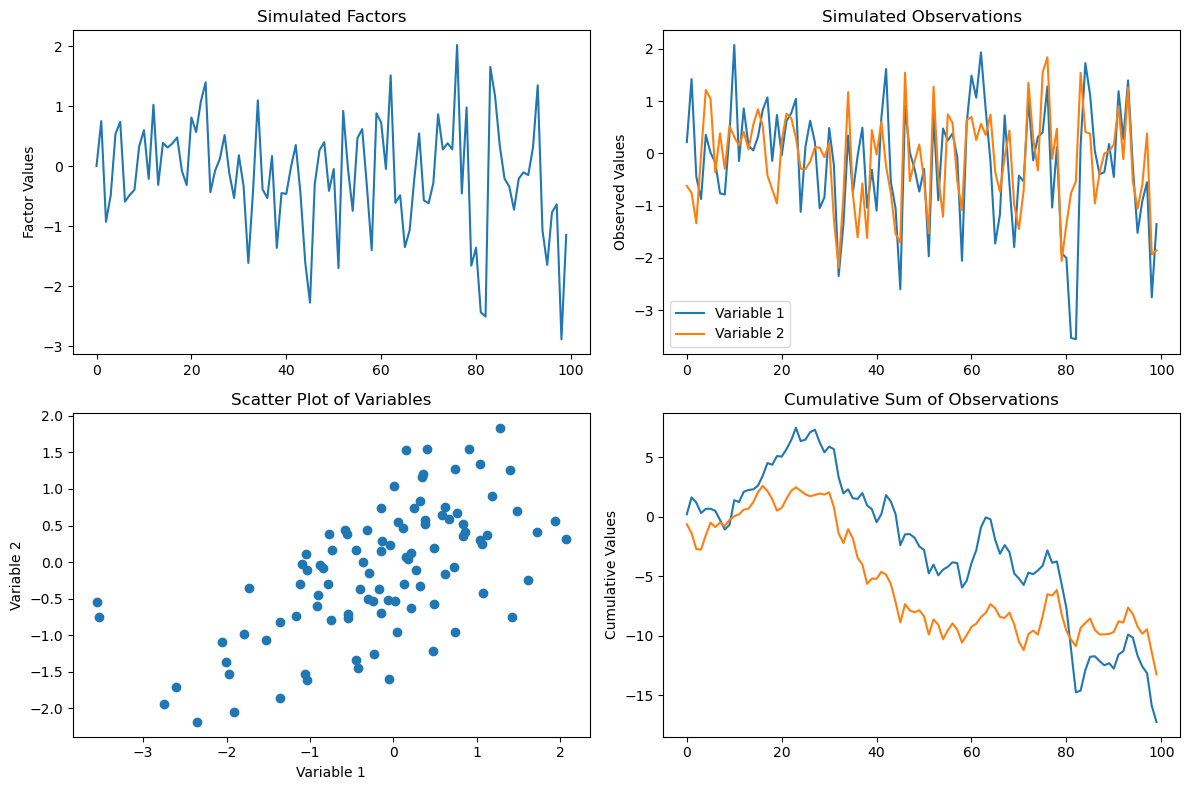

(array([[ 0.        ],
        [ 0.7504512 ],
        [-0.92695391],
        [-0.48027811],
        [ 0.53765288],
        [ 0.73633578],
        [-0.59071471],
        [-0.48021972],
        [-0.39463934],
        [ 0.33498951],
        [ 0.59831576],
        [-0.21308485],
        [ 1.02242987],
        [-0.31326628],
        [ 0.38652113],
        [ 0.30994637],
        [ 0.37856874],
        [ 0.47840377],
        [-0.08046933],
        [-0.31537692],
        [ 0.8105899 ],
        [ 0.56804801],
        [ 1.07737124],
        [ 1.3966615 ],
        [-0.43495646],
        [-0.0750525 ],
        [ 0.12101344],
        [ 0.51728196],
        [-0.12309691],
        [-0.5309508 ],
        [ 0.18105578],
        [-0.33277042],
        [-1.61349768],
        [-0.40697462],
        [ 1.09574099],
        [-0.38574718],
        [-0.53190667],
        [ 0.16847031],
        [-1.3618227 ],
        [-0.44823514],
        [-0.4634732 ],
        [-0.01173991],
        [ 0.3510011 ],
        [-0

In [17]:
compare_simulations()

In [18]:
validate_with_statsmodels()

Comparing simulations...
Custom simulation 1 (seed=42):
First 3 observations: [[ 0.2549446  -0.80556822]
 [ 1.56431682 -1.15257487]
 [-0.37173527 -1.51240433]]
Last 3 observations: [[-0.55156358  0.63572986]
 [-2.78613379 -1.82784207]
 [-1.41890056 -2.13395372]]

Custom simulation 2 (seed=123):
First 3 observations: [[-0.8275583  -0.28488632]
 [ 0.99040006  1.6576821 ]
 [ 0.49896302  1.58485009]]
Last 3 observations: [[-0.24265346 -0.19130424]
 [-0.69023217  0.62628451]
 [-0.14559419  1.00582936]]

Statistical properties (seed=42):
Observations mean: [-0.17877517 -0.13468039]
Observations std: [1.19820999 0.9895755 ]
Factor-observation correlation: 0.785, 0.635


(array([[ 2.54944600e-01, -8.05568225e-01],
        [ 1.56431682e+00, -1.15257487e+00],
        [-3.71735267e-01, -1.51240433e+00],
        [-9.60948755e-01,  6.57038907e-02],
        [ 3.27653455e-01,  1.43825750e+00],
        [-1.18727106e-01,  1.17714231e+00],
        [-1.09250710e-01, -3.34822106e-01],
        [-8.32947266e-01,  6.04125573e-01],
        [-8.73839982e-01, -2.91982544e-01],
        [ 3.99777174e-01,  5.94811597e-01],
        [ 2.36962977e+00,  2.61890886e-01],
        [-1.40169243e-01,  2.41639213e-01],
        [ 8.45494447e-01,  2.90793614e-01],
        [ 2.32508352e-01,  1.66964096e-01],
        [-3.15715247e-03,  6.14321426e-01],
        [ 3.21509276e-01,  1.01449428e+00],
        [ 9.25754717e-01,  5.85162666e-01],
        [ 1.19275416e+00, -6.61292728e-01],
        [-1.61088091e-01, -8.72452842e-01],
        [ 9.31452135e-01, -1.16539465e+00],
        [-1.92342417e-01,  1.15143154e-01],
        [ 6.32962674e-01,  8.45353522e-01],
        [ 7.26557574e-01,  6.210

In [19]:
print(y_traj)  # Print first 5 observed values

NameError: name 'y_traj' is not defined

In [23]:
import pymc as pm

In [24]:
# Unpack dims and coords
x0_dims, P0_dims, factor_loadings_dims, factor_ar_dims, error_ar_dims, error_sigma_dims, beta_dims = dfm_mod.param_dims.values()
coords = dfm_mod.coords

In [26]:
import pytensor.tensor as pt

In [27]:
with pm.Model(coords=coords) as pymc_mod:
    exog_data = pm.Data("exog_data",exog)

    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(5))
    P0 = pm.Deterministic("P0", pt.eye(5))
    factor_loadings = pm.Normal("factor_loadings", sigma=1, dims=factor_loadings_dims)
    factor_ar = pm.Normal("factor_ar", sigma=1, dims=factor_ar_dims)
    #factor_sigma = pm.Deterministic("factor_sigma", pt.constant([1.0], dtype=float))
    error_ar = pm.Normal("error_ar", sigma=1, dims=error_ar_dims)
    sigmas = pm.HalfNormal("error_sigma", dims=error_sigma_dims)
    beta = pm.Normal("beta", sigma=1, dims=beta_dims)
    # Build symbolic graph
    dfm_mod.build_statespace_graph(data=endog, mode="JAX")

/Users/andrea/Desktop/gitProject/pymc-extras/pymc_extras/statespace/utils/data_tools.py:74: UserWarning: No time index found on the supplied data. A simple range index will be automatically generated.
  warnings.warn(NO_TIME_INDEX_WARNING)


In [28]:
matrix_names = [
    "initial_state",
    "initial_state_cov",
    "state_intercept",
    "obs_intercept",
    "transition",
    "design",
    "selection",
    "obs_cov",
    "state_cov",
]


def print_model_ssm(mod, how="eval"):
    nice_heading = f'{"name":<20}{"__repr__":<50}{"shape":<10}{"value":<20}'
    print(nice_heading)
    print("=" * len(nice_heading))
    if how == "eval":
        matrices = [x.eval() for x in mod._unpack_statespace_with_placeholders()]
    elif how == "draw":
        matrices = pm.draw(mod.unpack_statespace())

    for name, value in zip(matrix_names, matrices):
        repr_ = str(mod.ssm[name])
        shape = str(mod.ssm[name].type.shape)
        value = str(value).replace("\n ", "\n" + " " * 81)
        print(f"{name:<20}{repr_:<50}{shape:<10}{value:<20}")
        print("-" * len(nice_heading))

In [29]:
print_model_ssm(dfm_mod, how="draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (5,)      [0. 0. 0. 0. 0.]    
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (5, 5)    [[1. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0.]
                                                                                 [0. 0. 0. 1. 0.]
                                                                                 [0. 0. 0. 0. 1.]]
----------------------------------------------------------------------------------------------------
state_intercept     state_intercept                                   (5,)      [0. 0. 0. 0. 0.]    
----

In [ ]:
dfm_mod.gra